About Dataset
Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths world wide.
Heart failure is a common event caused by CVDs and this dataset contains 12 features that can be used to predict mortality by heart failure.
Most cardiovascular diseases can be prevented by addressing behavioural risk factors such as tobacco use, unhealthy diet and obesity, physical inactivity and harmful use of alcohol using population-wide strategies.
People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyper lipid or already established disease) need early detection and management wherein a machine learning model can be of great help.

First import packages

In [1]:
import pandas as pd #table view 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/heart-failure-prediction-dataset/heart_failure_clinical_records_dataset.csv


In [2]:
#read the dataset into a datafrma table called df then view
df =  pd.read_csv("/kaggle/input/heart-failure-prediction-dataset/heart_failure_clinical_records_dataset.csv")
df.head(4) #view the first five rows n the table

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1


view data dimension

In [ ]:
print(f"data dimention is: {df.shape}") #shows number of rows and columns
print("--"*20)
print(f"column names are \n: {df.columns}") #view column names in the table

there are 299 rows and 13 different columns

In [ ]:
df.info()

## Observations

- Number of Entries: There are 1825 entries (rows) in the dataset.
- Data Types: The dataset consists of:
  - 10 columns of type int64 (integer).
  - 3 columns of type float64 (floating-point).
  

In [ ]:
df.nunique() #number of unique values in each columne

In [ ]:
#view number of missing values in each column
df.isnull().sum()

## Observations

- there are zero missing values in each column. in order word, there are no missing values or empty field in the data

##Understand simple descriptive statistics

In [ ]:
df.describe().T #this calculate the count, mean, std, min etc of each columns

### Summary Statistics


The dataset has 299 entries with the following insights:
- Age: Mean of 61 with a range from 40 to 95 years old.
- Anemia: Mean of 0.42, with a range from 0 to 1.
- creatinine_phosphokinase: Mean of 582 range of 23 and 7861.
- high_blood_pressure: has two values, 0 = no disease and 1 = disease-present
- Platelets: Average of 263358 with a range of 25100 and 850000.
- Death_event: has two values 1 died and 0 for alive.
- ejection_fraction: mean of 38 and a range between 14 and 80
- sex: has two values, 0 = female and 1 = male
- serum_creatinine: mean of 1.4 with a range from 0.5 to 1.4

# EDA
lets visualize some of the relationships between the variables in the column

In [3]:
df['death_status'] = df['DEATH_EVENT'].map({1:"dead", 0:"alive"}) #add a new column labeled "alive" =0 and "died" =11
df.head(5) #view the first fewe rows with the newly added column

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,death_status
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1,dead
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1,dead
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1,dead
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1,dead
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1,dead


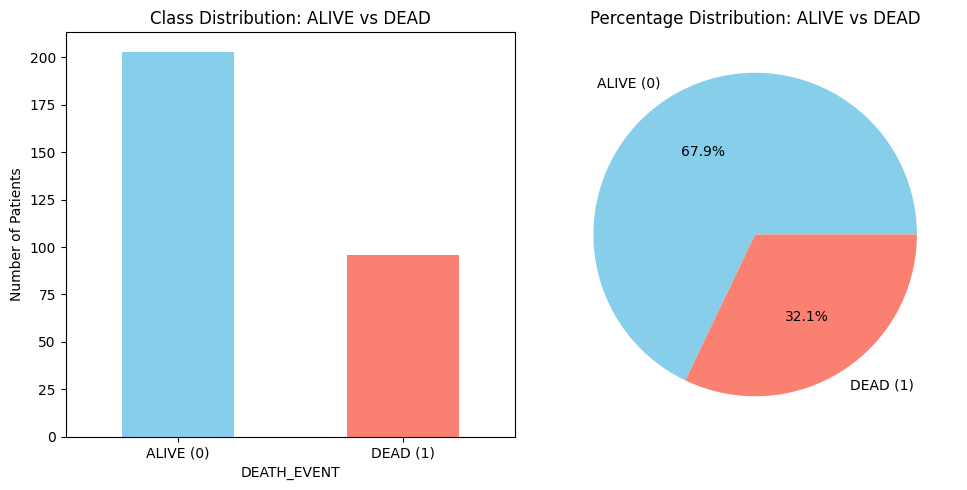

In [4]:
import matplotlib.pyplot as plt

# Analyzing the distribution of alive (1) vs. dead (0) in the training set
death_distribution = df['DEATH_EVENT'].value_counts()

# Bar plot for class distribution
plt.figure(figsize=(10, 5))

# Creating the bar plot
plt.subplot(1, 2, 1)
death_distribution.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Class Distribution: ALIVE vs DEAD")
plt.xticks([0, 1], ['ALIVE (0)', 'DEAD (1)'], rotation=0)
plt.ylabel("Number of Patients")

# Pie chart for class distribution
plt.subplot(1, 2, 2)
plt.pie(death_distribution, labels=['ALIVE (0)', 'DEAD (1)'], autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title("Percentage Distribution: ALIVE vs DEAD")

# Show the plots
plt.tight_layout()
plt.show()

#DEAD VS ALIVE DISTRIBUTION

here the distribution of dead vs. alive is 32.2% to 67.8% indicating that the data is skewed. this may affect our prediction result.

# Observation
the plot above indicates that there are more living patients (1) compared to the deceased patients (0).

THE new column called dead_status will be used to plot comparison between variables

In [5]:
#create creatinine_phosphokinase ranges/intervals for different patient groups
df['creatinine_bracket'] = pd.cut(
    df['creatinine_phosphokinase'],
    bins=[0, 500, 2000, 3000, 5000, 8000],
    labels=['0–500', '500–2000', '2000–3000', '3000–5000', '5000–8000'],
    right=False
)

#create ejection_fraction ranges/intervals for different patient groups
df['ejection_bracket'] = pd.cut(
                            df['ejection_fraction'], 
                            bins = [10, 20,30,40,50,85],
                           labels = ["0-20","20-30","30-40","40-50","50+"],
                           right=False)

#create time range or time interval for patients that survive vs died
df['time_bracket'] = pd.cut(
                            df['time'], 
                            bins = [4, 50,100,150,200,300],
                           labels = ["0-50","50-100","100-150","150-200","200+"],
                           right=False)

#create intervals for platelets to group patients
df['platelets_level']= pd.cut(df['platelets'], 
                              bins= [24275.1, 190080.0,355060.0,520040, 685020.0,950000.0],
                             labels =['24k-190k','190k-355k','355k-520k','520k-685k','685k-850k+'],
                             right = False)

#create a new column for age range or with intervals
df['age_bracket'] = pd.cut(
    df['age'],
    bins=[30, 50, 60, 75, 95],
    labels=[ '30–45', '45–60', '60–75', '75+'],
    right=False)

#create a new column for serum_sodium range or with intervals for different patient group
df['serum_sodium_level']= pd.cut(df['serum_sodium'], bins= [100,120,130,140,150,160],
                                 labels = ['100-120','120-130','130-140','140-150','150+'],
                                 right = False)

In [ ]:
df.columns

In [7]:
variable_ranges = (
    df.value_counts(['death_status','creatinine_bracket','age_bracket',
                     'time_bracket','serum_sodium_level','platelets_level',
                     'ejection_bracket'])
      .reset_index(name='count'))

#-----------------------------------------------------------------------------
death_by_time = (
    variable_ranges.pivot_table(index='death_status',
                   columns='time_bracket',
                   values='count',
                   aggfunc='sum',
                   fill_value=0,
                   observed=False ))

age_vs_time = (
    variable_ranges.pivot_table(index='age_bracket',
                   columns='time_bracket',
                   values='count',
                   aggfunc='sum',
                   fill_value=0,
                   observed=False ))

#--------------------------------------------------------------------------------
death_by_creatinine_phosph = (
    variable_ranges.pivot_table(index='death_status',
                   columns='creatinine_bracket',
                   values='count',
                   aggfunc='sum',
                   fill_value=0,
                   observed=False ))  

by_age = variable_ranges.pivot_table(
    index='age_bracket',
    columns='creatinine_bracket',
    values='count',
    aggfunc='sum',
    fill_value=0,
    observed=False )  



death_by_age = by_age.reset_index().melt(id_vars='age_bracket', 
                                    var_name='creatinine_bracket', 
                                    value_name='count')

death_by_serum_sodium = (
    variable_ranges.pivot_table(index='death_status',
                   columns='serum_sodium_level',
                   values='count',
                   aggfunc='sum',
                   fill_value=0,
                   observed=False ))

age_vs_serum_sodium = (
    variable_ranges.pivot_table(index='age_bracket',
                   columns='serum_sodium_level',
                   values='count',
                   aggfunc='sum',
                   fill_value=0,
                   observed=False ))

#--------------------------------------------------------------------
death_by_ejection_fraction =(
    variable_ranges.pivot_table(
        index = "death_status",
        columns = 'ejection_bracket',
        values = 'count',
    aggfunc ='sum',
    fill_value =0,
    observed = False))

ejection_fraction_by_age = (
            variable_ranges.pivot_table(
            index = 'age_bracket',
            columns ='ejection_bracket',
            values = 'count',
            aggfunc ='sum',
            fill_value = 0,
            observed = False))
        

#--------------------------------------------------------------------
death_by_platelets =(
    variable_ranges.pivot_table(
        index = "death_status",
        columns = 'platelets_level',
        values = 'count',
    aggfunc ='sum',
    fill_value =0,
    observed = False))

platelets_level_by_age = (
            variable_ranges.pivot_table(
            index = 'age_bracket',
            columns ='platelets_level',
            values = 'count',
            aggfunc ='sum',
            fill_value = 0,
            observed = False))

In [80]:
df.age_bracket.value_counts() 

age_bracket
60–75    129
45–60     82
30–45     47
75+       39
Name: count, dtype: int64

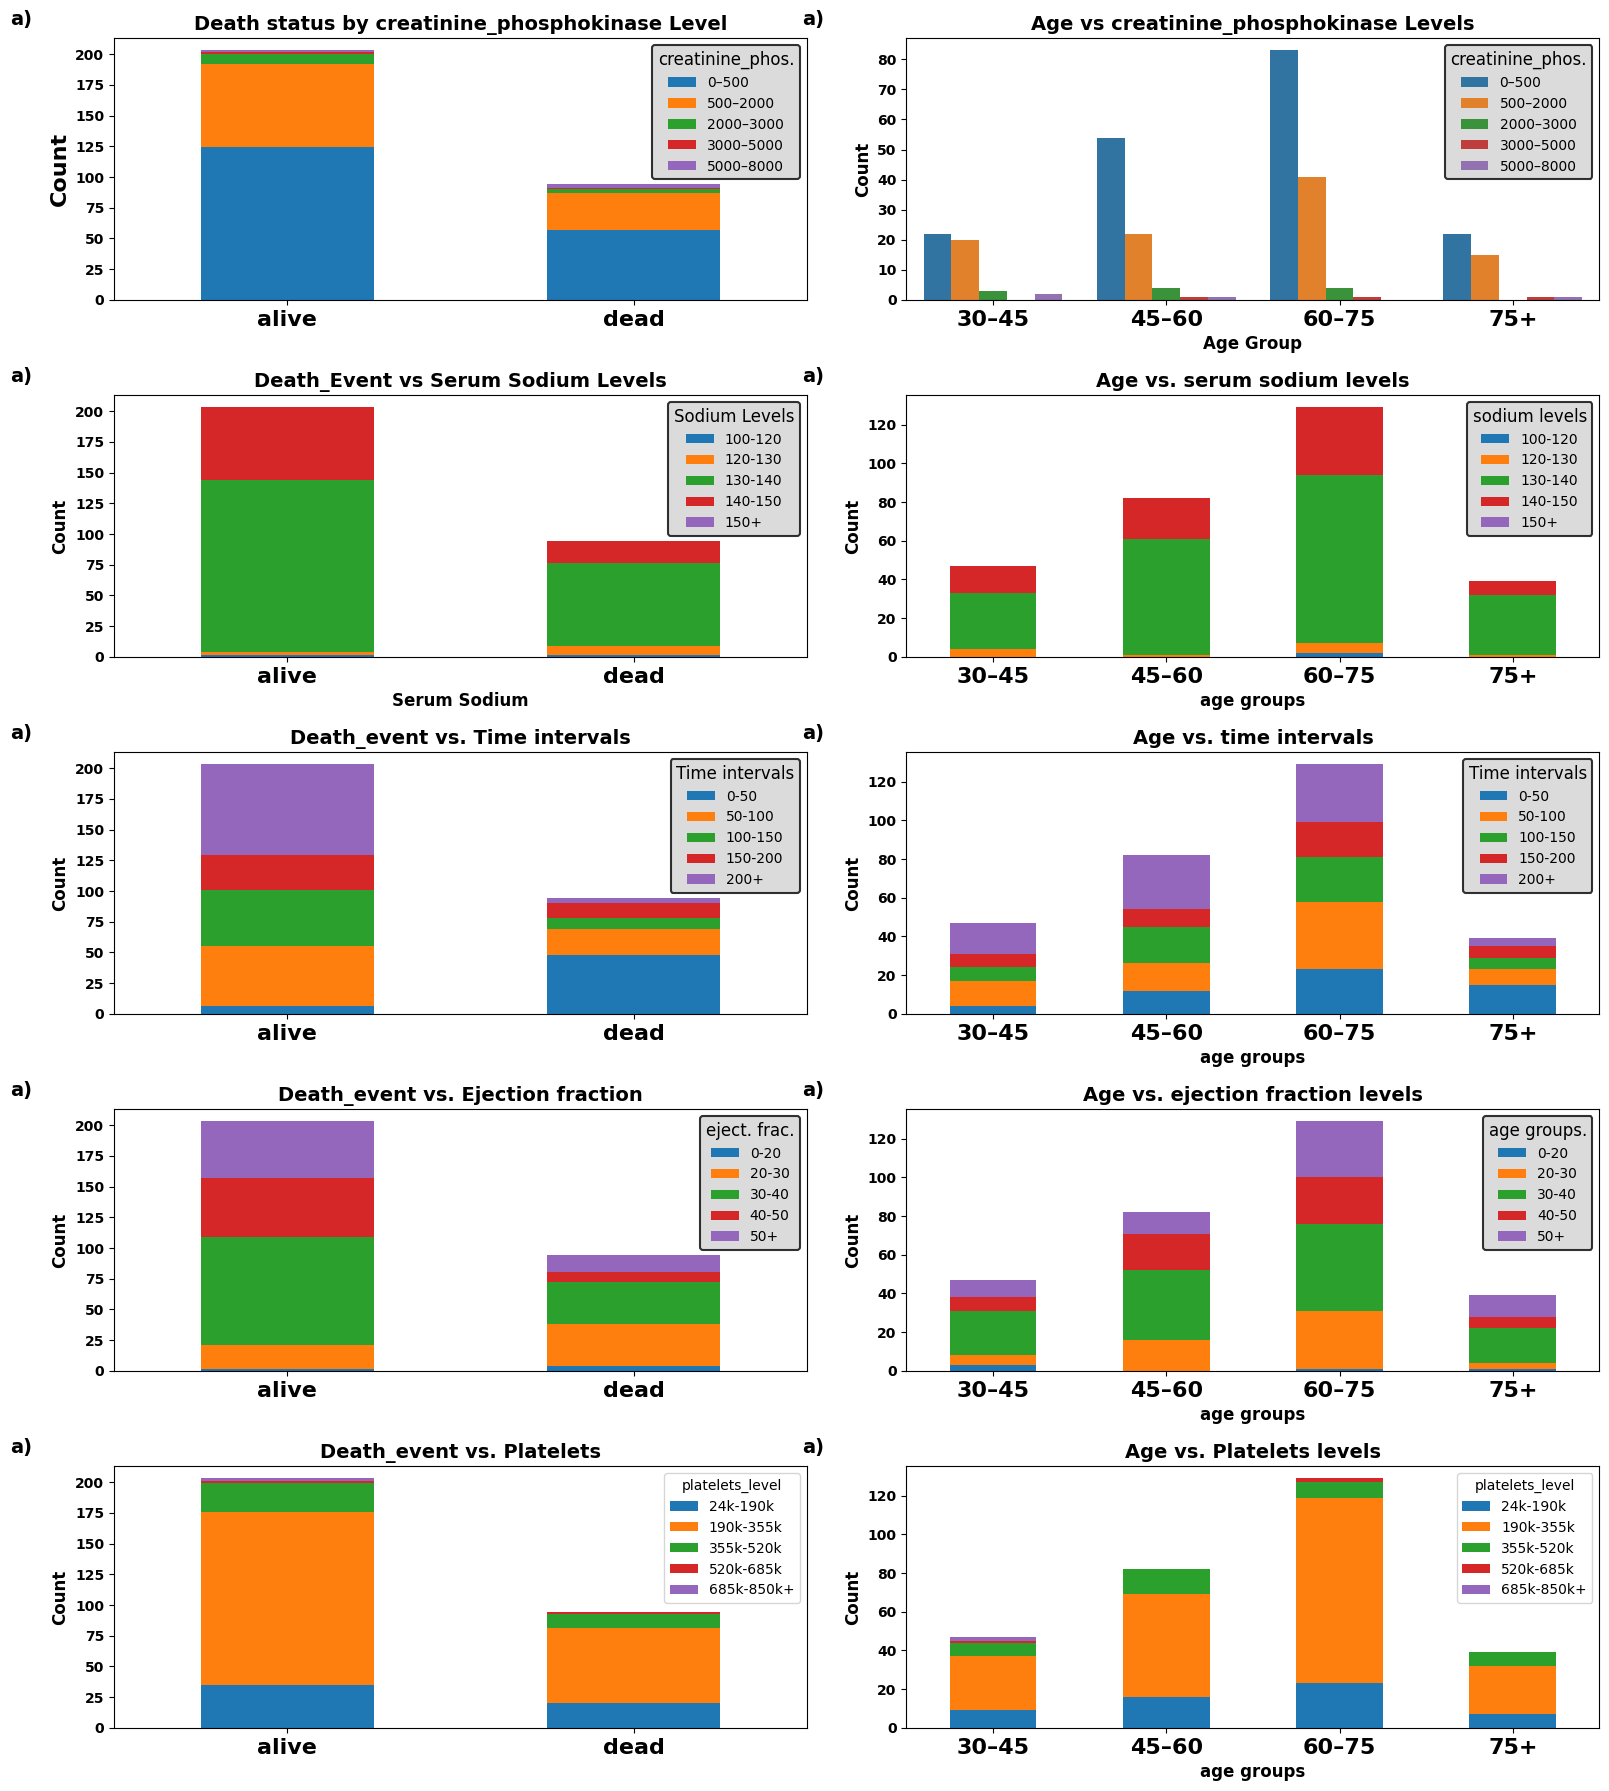

In [14]:
fig, axes = plt.subplots(5, 2, figsize=(16, 18))


death_by_creatinine_phosph.plot(kind='bar', stacked=True, ax = axes[0,0])
axes[0,0].set_title("Death status by creatinine_phosphokinase Level", fontsize=14, fontweight='bold')
axes[0,0].set_xlabel("")
axes[0,0].set_ylabel("Count", fontsize=16, fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=0, labelsize=16)

# Set font weight
for tick in axes[0,0].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[0,0].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[0,0].text(-0.15, 1.05, "a)", transform=axes[0,0].transAxes,
               fontsize=14, fontweight='bold')

leg = axes[0,0].legend(title='creatinine_phos.', fontsize=10, title_fontsize=12)
# Optional: make legend frame fancy
leg.get_frame().set_edgecolor('black')
leg.get_frame().set_linewidth(1.5)
leg.get_frame().set_facecolor('lightgray')

# --- ---------------------------------------------------------- ---
sns.barplot(data = death_by_age, x='age_bracket', y='count', hue='creatinine_bracket', ax=axes[0,1])
axes[0,1].set_title("Age vs creatinine_phosphokinase Levels", fontsize=14, fontweight='bold')
axes[0,1].set_xlabel("Age Group", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[0,1].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[0,1].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[0,1].text(-0.15, 1.05, "a)", transform=axes[0,1].transAxes,
               fontsize=14, fontweight='bold')

leg_1 = axes[0,1].legend(title='creatinine_phos.', fontsize=10, title_fontsize=12)
# Optional: make legend frame fancy
leg_1.get_frame().set_edgecolor('black')
leg_1.get_frame().set_linewidth(1.5)
leg_1.get_frame().set_facecolor('lightgray')


# --- ---------------------------------------------------------- ---

death_by_serum_sodium.plot(kind='bar', stacked=True, ax = axes[1,0])
axes[1,0].set_title("Death_Event vs Serum Sodium Levels", fontsize=14, fontweight='bold')
axes[1,0].set_xlabel("Serum Sodium", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[1,0].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[1,0].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[1,0].text(-0.15, 1.05, "a)", transform=axes[1,0].transAxes,
               fontsize=14, fontweight='bold')

leg_2 = axes[1,0].legend(title='Sodium Levels', fontsize=10, title_fontsize=12)
# Optional: make legend frame fancy
leg_2.get_frame().set_edgecolor('black')
leg_2.get_frame().set_linewidth(1.5)
leg_2.get_frame().set_facecolor('lightgray')


age_vs_serum_sodium.plot(kind='bar', stacked=True, ax = axes[1,1])
axes[1,1].set_title("Age vs. serum sodium levels", fontsize=14, fontweight='bold')
axes[1,1].set_xlabel("age groups", fontsize=12, fontweight='bold')
axes[1,1].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[1,1].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[1,1].get_yticklabels():
    tick.set_fontweight('bold')
axes[1,1].text(-0.15, 1.05, "a)", transform=axes[1,1].transAxes,
               fontsize=14, fontweight='bold')

leg_3 = axes[1,1].legend(title='sodium levels', fontsize=10, title_fontsize=12)
# Optional: make legend frame fancy
leg_3.get_frame().set_edgecolor('black')
leg_3.get_frame().set_linewidth(1.5)
leg_3.get_frame().set_facecolor('lightgray')
# --- ---------------------------------------------------------- ---

death_by_time.plot(kind='bar', stacked=True, ax = axes[2,0])
axes[2,0].set_title("Death_event vs. Time intervals", fontsize=14, fontweight='bold')
axes[2,0].set_xlabel(" ", fontsize=12, fontweight='bold')
axes[2,0].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[2,0].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[2,0].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[2,0].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[2,0].text(-0.15, 1.05, "a)", transform=axes[2,0].transAxes,
               fontsize=14, fontweight='bold')

leg_4 = axes[2,0].legend(title='Time intervals', fontsize=10, title_fontsize=12)
# Optional: make legend frame fancy
leg_4.get_frame().set_edgecolor('black')
leg_4.get_frame().set_linewidth(1.5)
leg_4.get_frame().set_facecolor('lightgray')


age_vs_time.plot(kind='bar', stacked=True, ax = axes[2,1])
axes[2,1].set_title("Age vs. time intervals", fontsize=14, fontweight='bold')
axes[2,1].set_xlabel("age groups", fontsize=12, fontweight='bold')
axes[2,1].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[2,1].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[2,1].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[2,1].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[2,1].text(-0.15, 1.05, "a)", transform=axes[2,1].transAxes,
               fontsize=14, fontweight='bold')

leg_5 = axes[2,1].legend(title='Time intervals', fontsize=10, title_fontsize=12)
# Optional: make legend frame fancy
leg_5.get_frame().set_edgecolor('black')
leg_5.get_frame().set_linewidth(1.5)
leg_5.get_frame().set_facecolor('lightgray')

### --- ---------------------------------------------------------- ---

death_by_ejection_fraction.plot(kind='bar', stacked=True, ax = axes[3,0])
axes[3,0].set_title("Death_event vs. Ejection fraction", fontsize=14, fontweight='bold')
axes[3,0].set_xlabel(" ", fontsize=12, fontweight='bold')
axes[3,0].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[3,0].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[3,0].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[3,0].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[3,0].text(-0.15, 1.05, "a)", transform=axes[3,0].transAxes,
               fontsize=14, fontweight='bold')

leg_5 = axes[3,0].legend(title='eject. frac.', fontsize=10, title_fontsize=12)
# Optional: make legend frame fancy
leg_5.get_frame().set_edgecolor('black')
leg_5.get_frame().set_linewidth(1.5)
leg_5.get_frame().set_facecolor('lightgray')


ejection_fraction_by_age.plot(kind='bar', stacked=True, ax = axes[3,1])
axes[3,1].set_title("Age vs. ejection fraction levels", fontsize=14, fontweight='bold')
axes[3,1].set_xlabel("age groups", fontsize=12, fontweight='bold')
axes[3,1].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[3,1].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[3,1].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[3,1].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[3,1].text(-0.15, 1.05, "a)", transform=axes[3,1].transAxes,
               fontsize=14, fontweight='bold')

leg_6 = axes[3,1].legend(title='age groups.', fontsize=10, title_fontsize=12)
# Optional: make legend frame fancy
leg_6.get_frame().set_edgecolor('black')
leg_6.get_frame().set_linewidth(1.5)
leg_6.get_frame().set_facecolor('lightgray')

####------------------------------------------

death_by_platelets.plot(kind='bar', stacked=True, ax = axes[4,0])
axes[4,0].set_title("Death_event vs. Platelets", fontsize=14, fontweight='bold')
axes[4,0].set_xlabel(" ", fontsize=12, fontweight='bold')
axes[4,0].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[4,0].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[4,0].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[4,0].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[4,0].text(-0.15, 1.05, "a)", transform=axes[4,0].transAxes,
               fontsize=14, fontweight='bold')



platelets_level_by_age.plot(kind='bar', stacked=True, ax = axes[4,1])
axes[4,1].set_title("Age vs. Platelets levels", fontsize=14, fontweight='bold')
axes[4,1].set_xlabel("age groups", fontsize=12, fontweight='bold')
axes[4,1].set_ylabel("Count", fontsize=12, fontweight='bold')
axes[4,1].tick_params(axis='x', rotation=0, labelsize=16)
for tick in axes[4,1].get_xticklabels():
    tick.set_fontweight('bold')
for tick in axes[4,1].get_yticklabels():
    tick.set_fontweight('bold')
    
axes[4,1].text(-0.15, 1.05, "a)", transform=axes[4,1].transAxes,
               fontsize=14, fontweight='bold')

leg_8 = axes[3,1].legend(title='age groups.', fontsize=10, title_fontsize=12)
#Optional: make legend frame fancy
leg_8.get_frame().set_edgecolor('black')
leg_8.get_frame().set_linewidth(1.5)
leg_8.get_frame().set_facecolor('lightgray')

plt.tight_layout()
plt.show()


In [15]:
plt.savefig("my_plot.png", dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [ ]:
ejection_fraction_by_age

In [ ]:
#here we calculate aggregate or group patient by age, sex, disease or not and compare it to motality status

#motality by age
average_age_vs_death = df.groupby('death_status')['age'].mean().reset_index()

#motality by sex
sex_vs_death_event = df.groupby('death_status')['sex'].value_counts().reset_index()

#motality with high blood pressure vs alive with disease
high_blood_pressure_vs_death = df.groupby('death_status')['high_blood_pressure'].value_counts().reset_index()

#motality by anemia vs alive with anemia
Anemia_vs_death = df.groupby('death_status')['anaemia'].value_counts().reset_index()

#average_age_vs_death

# Observation
asumine the value 1 = alive and 0 = dead, the plot above shows that older patient have high motality rate compread to younger patients

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# --- Plot 1: Count by death status & sex ---
sns.barplot(
    x='death_status', y='count', hue='sex',
    data=sex_vs_death_event, ax=axes[0,0]
)
axes[0,0].set_title("Death Status Count by Sex", fontsize=14, fontweight='bold')
axes[0,0].set_xlabel("Death Status", fontsize=12, fontweight='bold')
axes[0,0].set_ylabel("Count", fontsize=12, fontweight='bold')

# Label
axes[0,0].text(-0.15, 1.05, "a)", transform=axes[0,0].transAxes,
               fontsize=14, fontweight='bold')


# --- Plot 2: Average Age by death status ---
sns.barplot(
    x='death_status', y='age',
    data=average_age_vs_death, ax=axes[0,1]
)
axes[0,1].set_title("Average Age by Death Status", fontsize=14, fontweight='bold')
axes[0,1].set_xlabel("Death Status", fontsize=12, fontweight='bold')
axes[0,1].set_ylabel("Average Age", fontsize=12, fontweight='bold')

# Label
axes[0,1].text(-0.15, 1.05, "b)", transform=axes[0,1].transAxes,
               fontsize=14, fontweight='bold')


# --- Plot 3: Anemia vs death status ---
sns.barplot(
    x='death_status', y='count', hue='anaemia',
    data=Anemia_vs_death, ax=axes[1,0]
)
axes[1,0].set_title("Anemia vs Death Status", fontsize=14, fontweight='bold')
axes[1,0].set_xlabel("Death Status", fontsize=12, fontweight='bold')
axes[1,0].set_ylabel("Count", fontsize=12, fontweight='bold')

# Label
axes[1,0].text(-0.15, 1.05, "c)", transform=axes[1,0].transAxes,
               fontsize=14, fontweight='bold')


# --- Plot 4: High BP vs death status ---
sns.barplot(
    x='death_status', y='count', hue='high_blood_pressure',
    data=high_blood_pressure_vs_death, ax=axes[1,1]
)
axes[1,1].set_title("High Blood Pressure vs Death Status", fontsize=14, fontweight='bold')
axes[1,1].set_xlabel("Death Status", fontsize=12, fontweight='bold')
axes[1,1].set_ylabel("Count", fontsize=12, fontweight='bold')

# Label
axes[1,1].text(-0.15, 1.05, "d)", transform=axes[1,1].transAxes,
               fontsize=14, fontweight='bold')
for ax in axes.ravel():
    ax.tick_params(axis='x', labelsize=16)   # 👈 change 14 to any size you want

for ax in axes.ravel():
    ax.tick_params(axis='y', labelsize=16)  # 👈 change 14 to any size you want


plt.tight_layout()
plt.show()


# Observation

from fig. (a) we observed that more patient in both sexes are alive compared to dead. however, we see that motality is higher in patients with sex = 1 compare to sex 0.

from fig. (b) asumine the value 1 = alive and 0 = dead, the plot above shows that older patient (60>) have high motality rate compread to younger patients (< 50).

from fig. (c) assuming 1 = anaemia and 0 = no-anaemia, then the obsevation indicates that more patient with anaemia survive (80) compared to patient with anaemia that died (48). additionally, patient without anaemia have a higher survival rate (120) compared to patient without the disease (45).

from fig. (d) assuming 1 = high BP and 0 = no-high-BP, then the obsevation indicates that more patient with the disease survive (63) compared to patient with the disease that died (42). Additionally, patient without high BP have a higher survival rate (140) compared to patient without the disease (45).

# correlation Heatmap
here I'll plot the correlation heatmap to understand the magnitude and direction of relationships between variables in the dataset

In [ ]:
df2 = df.drop(['death_status'], axis=1)
plt.figure(figsize = (18,10))

sns.heatmap(df2.corr(), annot =True, fmt = ".2f", cmap = 'coolwarm', annot_kws = {"size": 14})
plt.title("Variable Correlation Heatmap", fontsize=18, fontweight='bold')  # 🔹 increase title size
plt.xticks(fontsize=14, rotation=45)  # 🔹 increase x-tick font size
plt.yticks(fontsize=14, rotation=0)   # 🔹 increase y-tick font size
plt.show()

#Observation
- time shows an average negative correlation with death_event. It also shows a weak negative corrlation with high BP, serum-creatinine, anaemia and age.
- age shows a weak positive relationship with death_event.
- death_event shows a weak positive relative with serum_creatinine indicating that the present of this disease can lead to death.
- Diabetes shows a weak negative relationship with smoking and sex. indicating that the disease is not sex and smoking related.
- serum_sodium shows a weak positive relationship with ejection_fraction. indicating that patient with one serum sodium is likely having ejection fraction
- smoking seems to have a relatively noticeable positive correlation with sex. indicating that one of the two genders are more prone smoking than the other.
- Platelets also have a weak positive relationship with death-event indicating that patient with platelets are at risk of dying.

# Machine learning Analysis of the Data
I will be using  ML model in the subsequent analysis

first we need to understand the distribution of the DEATH_EVENT predictor variable

In [ ]:
X = df.drop(columns = ['DEATH_EVENT','death_status','creatinine_bracket','age_bracket']) #assign predictors to x
y = df['DEATH_EVENT'] #assign predictor variable to y

print(X.head(1))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 
#split the data into training and testing sets with ratio 70/30
X_train[:2]

scaling the data make sure that values are standardized with a specific range, eliminating the possible of atleast one variable influencing the result

In [ ]:
#applying standard scalar to scale the dataset
scaler = StandardScaler() #using standard scalr algorithm for normalization
X_train_scaled = scaler.fit_transform(X_train) #apply the algorithm to the training and testing data
X_test_scaled = scaler.transform(X_test)

X_test_scaled[:2]  #take a peak at the result of the scaled data

In [ ]:
#I will first run the randomforestclassifier
#import libraries
from sklearn.ensemble import RandomForestClassifier

#initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) 

#train the model
rf_model.fit(X_train_scaled, y_train)

#predict the death event
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Print classification report
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Function to evaluate model performance on both training and test sets
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Training Set Performance
    y_train_pred = model.predict(X_train)
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)
    f1_train = f1_score(y_train, y_train_pred)
    cm_train = confusion_matrix(y_train, y_train_pred)

    print("Training Set Performance:")
    print(f"Precision: {precision_train:.2f}")
    print(f"Recall: {recall_train:.2f}")
    print(f"F1-Score: {f1_train:.2f}")
    print(f"Confusion Matrix:\n{cm_train}\n")

    # Test Set Performance
    y_test_pred = model.predict(X_test)
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)
    f1_test = f1_score(y_test, y_test_pred)
    cm_test = confusion_matrix(y_test, y_test_pred)

    print("Test Set Performance:")
    print(f"Precision: {precision_test:.2f}")
    print(f"Recall: {recall_test:.2f}")
    print(f"F1-Score: {f1_test:.2f}")
    print(f"Confusion Matrix:\n{cm_test}\n")

# Underfitting Random Forest with low max_depth (underfitted model)
rf_underfit = RandomForestClassifier(random_state=42, max_depth=2)
rf_underfit.fit(X_train_scaled, y_train)

# Evaluate the underfitted Random Forest on training and test sets
print("=== Underfitting Random Forest ===")
evaluate_model(rf_underfit, X_train_scaled, y_train, X_test_scaled, y_test)


#Interpretation:
Precision (0.89-93): Prioritizes reducing false positives. Interpretation of 0.89–0.93
If precision is 0.89–0.93, it means 89–93% of patients predicted as having died from heart disease actually do died from it. This is high precision, which is good because it reduces false alarms.

Recall (0.42-0.66): Recall of 0.42–0.66 means the model only catches 42–66% of real heart disease cases. In other words, 34–58% of patients who truly have heart disease or died of heart are missed (false negatives). That’s a moderate-to-low sensitivity, which is concerning in healthcare.

F1-Score (0.61): If F1 = 0.57 → moderate performance: the model catches some patients but misses others or produces some false positives.

If F1 = 0.77 → fairly strong performance: the model is reasonably balanced in detecting heart disease while keeping false alarms low.

#What the result generally indicates

✔ learns the training data too well
✔ memorizes noise, patterns, and randomness
✔ becomes too specialized to the training set
✖ and fails to generalize to unseen data (testing set)

So it predicts training patients well —
but struggles on new patients.

❤️ In a medical (heart disease) context

That means:

The model appears accurate in the development phase,
but might not be reliable in real-world clinical use.
Because real patients = unseen data.

##Why does this happen?

* -Common causes:
* --Model too complex (e.g., deep networks on small data)
* --Small dataset (we only have 299 patient to work with, which may impact the model)
* --Too many features
* --Not enough regularization
* --Data leakage
* --Poor validation strategy


In [ ]:
importances = rf_model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()